# Retail Sales Data Analysis
## Oasis Infobyte - Data Analytics Internship
### Task 1: Exploratory Data Analysis (EDA)

This project analyzes retail sales data to understand sales trends, customer characteristics, product category performance, and relationships between numerical variables. Python, Pandas, Matplotlib, and Seaborn are used to explore the dataset and generate meaningful business insights.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("retail_sales_dataset.csv")

In [48]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [49]:
df.shape

(1000, 9)

In [50]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [52]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [55]:
df.median(numeric_only = True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [56]:
df.mode(numeric_only = True).iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [57]:
df.std(numeric_only = True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [58]:
df['Date'] = pd.to_datetime(df['Date'])

In [59]:
df['Date'].dtype

dtype('<M8[ns]')

In [60]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

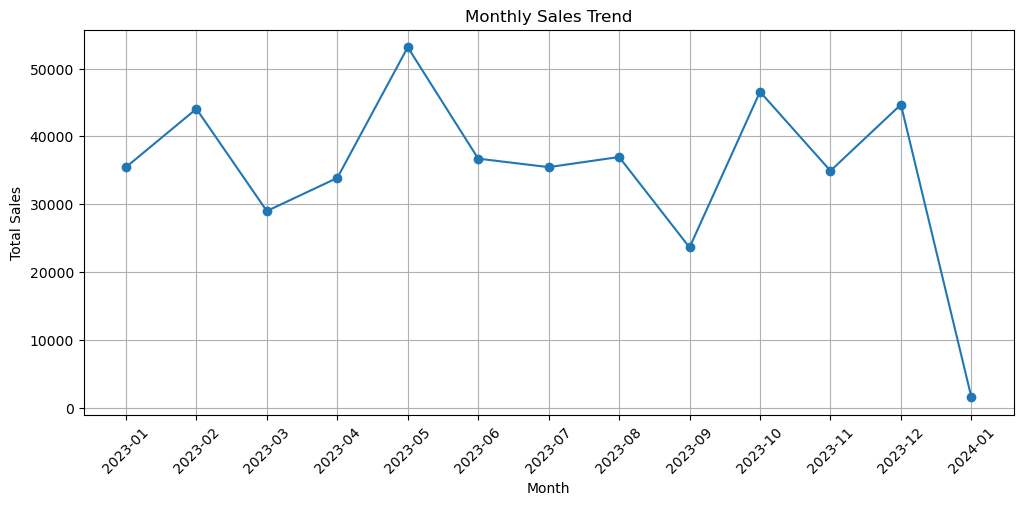

In [76]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker = 'o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation – Monthly Sales Trend

Monthly sales fluctuated considerably throughout the period. Sales reached their highest monthly value of 53,150 in May 2023, while September 2023 recorded the lowest monthly sales among the complete months at 23,620. January 2024 shows a sharp decline to 1,530 because the dataset contains only January 2024 records.

In [62]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()
quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

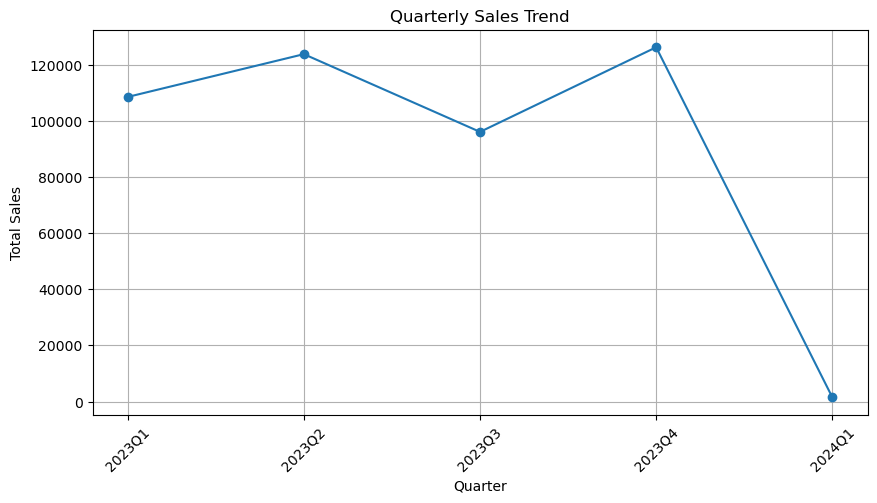

In [63]:
plt.figure(figsize=(10,5))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker = 'o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation - Quarterly Sales Trend

Quarterly Sales increased from 108,500 in Q1 2023 to 123,735 in Q2, then declined to 96,045 in Q3. Sales reached the highest quarterly value of 126,190 in Q4 2023. Q1 2024 shows a sharp decline to 1,530 because the dataset contains only January 2024 records, so it should not be directly compared with the complete quarters of 2023.

In [64]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [65]:
age_group_counts = df['Age Group'].value_counts().sort_index()
age_group_counts

Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

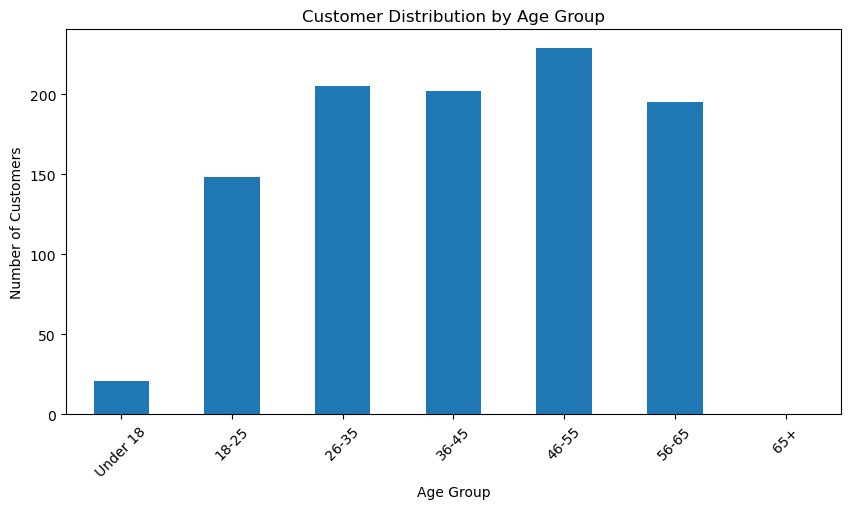

In [77]:
plt.figure(figsize=(10, 5))
age_group_counts.plot(kind='bar')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

### Observation - Customer Age Group Distribution

The 46-55 age group has the highest representation with 229 customers, followed by the 26-35 and 36-45 groups with 205 and 202 customers respectively. The dataset contains 195 customers in the 56-65 group and only 21 customers under 18. There are no customers in the 65+ group.

In [67]:
gender_counts = df['Gender'].value_counts()
gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

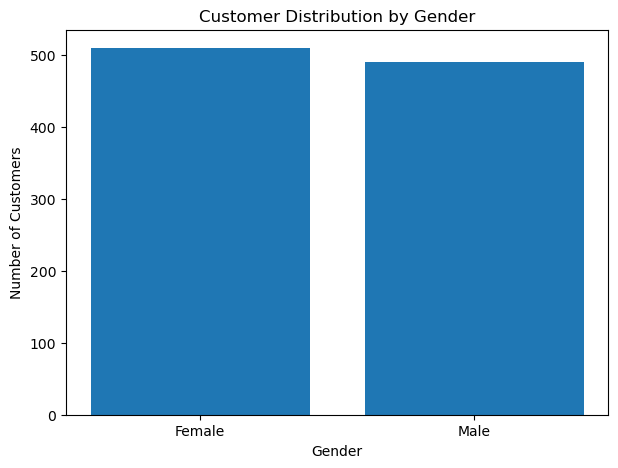

In [68]:
plt.figure(figsize=(7,5))
plt.bar(gender_counts.index, gender_counts.values)
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Observation - Gender Distribution

The customer distribution is fairly balanced by gender. Female customers account for 510 records, while male customers account for 490 records. The small difference indicates that neither gender strongly dominates the customer base in this dataset.

In [69]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

In [70]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

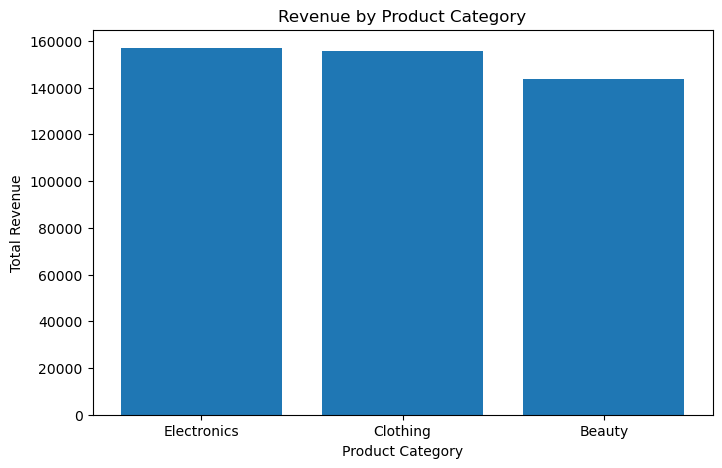

In [71]:
plt.figure(figsize=(8,5))
plt.bar(category_revenue.index, category_revenue.values)
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.show()

### Observation - Product Category Analysis
Clothing has the highest total quantity sold with 894 units, followed by Electronics with 849 units and Beauty with 771 units. However, Electronics generates the highest revenue at 156,905, slightly ahead of Clothing at 155,580. This indicates that Electronics contributes the most revenue despite having a lower sales volume than Clothing.

### Data Limitation - Product-Level Analysis

The data does not contain an individual product name or product ID column. Therefore, a Top 10 individual product analysis cannot be performed reliably. Instead, the analysis focuses on sales quantity and revenue by product category using the available data.

In [72]:
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


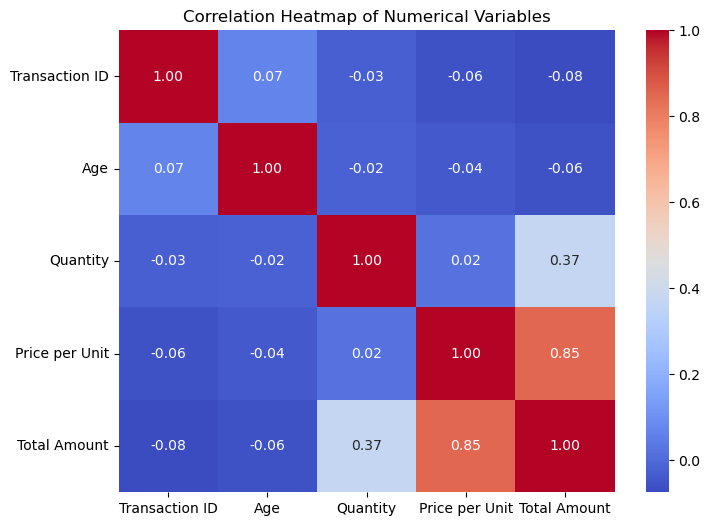

In [73]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Observation - Correlation Analysis
The heatmap shows a strong positive correlation of 0.85 between Price per Unit and Total Amount, indicating that higher-priced transactions generally contribute to higher transaction values. Quantity has a moderate positive correlation of 0.37 with Total Amount, suggesting that purchasing more units tends to increase the total transaction value. Age has very weak correlations with both Quantity (-0.02) and Total Amount (-0.06), indicating little direct relationship with purchasing value in this dataset. Transaction ID is an identifier and does not provide meaningful business insight. 

In [74]:
avg_spending_age = df.groupby('Age Group', observed=True)['Total Amount'].mean()
avg_spending_age

Age Group
Under 18    534.047619
18-25       495.506757
26-35       480.390244
36-45       454.801980
46-55       439.694323
56-65       412.358974
Name: Total Amount, dtype: float64

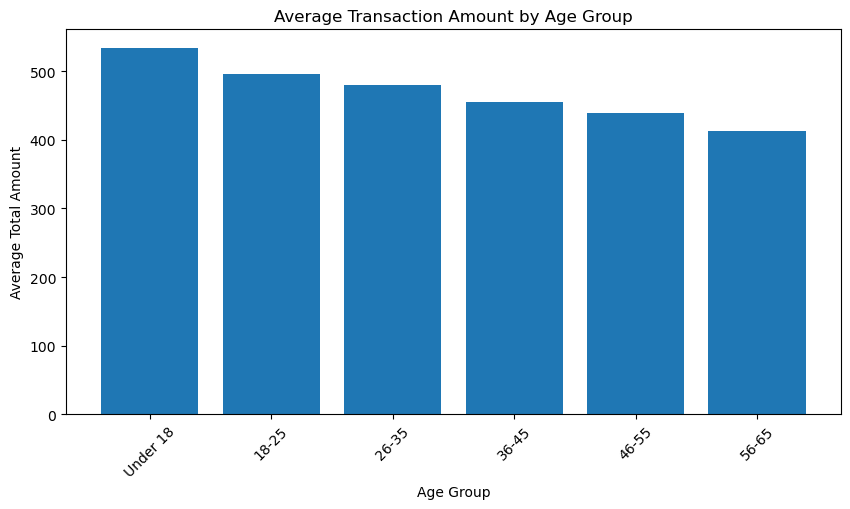

In [75]:
plt.figure(figsize=(10,5))
plt.bar(avg_spending_age.index.astype(str), avg_spending_age.values)
plt.title('Average Transaction Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Total Amount')
plt.xticks(rotation=45)
plt.show()

### Observation - Average Transaction Amount by Age Group
The average transaction amount generally decreases across the age groups in this dataset. The under-18 group has the highest average transaction amount at approximately 534.05, while the 56-65 group has the lowest at approximately 412.36. However, the under-18 group contains only 21 records, so this result should be interpreted cautiously rather than generalized to the wider population. 

## Conclusion and Business Recommendations

### Key Findings

- Clothing has the highest sales volume with 894 units, while Electronics generates the highest revenue at 156,905.
- Price per Unit has a strong positive correlation with Total Amount (0.85), while Quantity has a moderate positive correlation (0.37).
- The customer distribution is almost balanced by gender, with 510 female and 490 male customers.
- Average transaction value generally decreases across the age groups, with the under-18 group showing the highest average transaction amount and the 56-65 group showing the lowest.

### Actionable Business Recommendations

1. **Focus on Electronics:** Since Electronics generates the highest revenue, the business can prioritize its promotion and visibility through targeted campaigns and product recommendations.

2. **Improve Clothing Revenue:** Clothing has the highest quantity sold but slightly lower revenue than Electronics. Bundling, premium product options, or value-based upselling could help increase the revenue generated from this category.


3. **Use Age-Based Marketing:** The analysis shows higher average transaction values among younger age groups. The business can test age-specific promotions and personalized campaigns for these customer segments while continuing to monitor their conversion and spending patterns.